# Stage 15 — Post-hoc Analysis (v1)

Loads Stage 14 CSVs and produces summary tables and figures answering **RQ1** and **RQ2**.

- **RQ1:** What do prototypes at each scale level actually learn?
- **RQ2:** Does multi-scale configuration diversify prototype representations, or does one level dominate?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

DATA_DIR = Path("../results/v4/proto_quality/v1")
OUT_DIR  = Path("../results/v4/proto_quality/v1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["LV", "RV", "LA", "RA", "Myo", "Aorta", "PA"]
LEVEL_LABELS = ["L1\n(128×128)", "L2\n(64×64)", "L3\n(32×32)", "L4\n(16×16)"]

In [2]:
# Cell 1 — Load all CSVs
purity_proto  = pd.read_csv(DATA_DIR / "purity_per_prototype.csv")
purity_sum    = pd.read_csv(DATA_DIR / "purity_summary.csv")
utilization   = pd.read_csv(DATA_DIR / "utilization.csv")
compactness   = pd.read_csv(DATA_DIR / "compactness.csv")
dice_sens     = pd.read_csv(DATA_DIR / "dice_sensitivity.csv")
level_dom     = pd.read_csv(DATA_DIR / "level_dominance.csv")
per_level_ap  = pd.read_csv(DATA_DIR / "per_level_ap.csv")

print("Loaded:")
for name, df in [("purity_proto", purity_proto), ("purity_sum", purity_sum),
                  ("utilization", utilization), ("compactness", compactness),
                  ("dice_sens", dice_sens), ("level_dom", level_dom),
                  ("per_level_ap", per_level_ap)]:
    print(f"  {name}: {df.shape}")

Loaded:
  purity_proto: (77, 6)
  purity_sum: (4, 4)
  utilization: (77, 6)
  compactness: (77, 6)
  dice_sens: (77, 7)
  level_dom: (1, 4)
  per_level_ap: (28, 4)


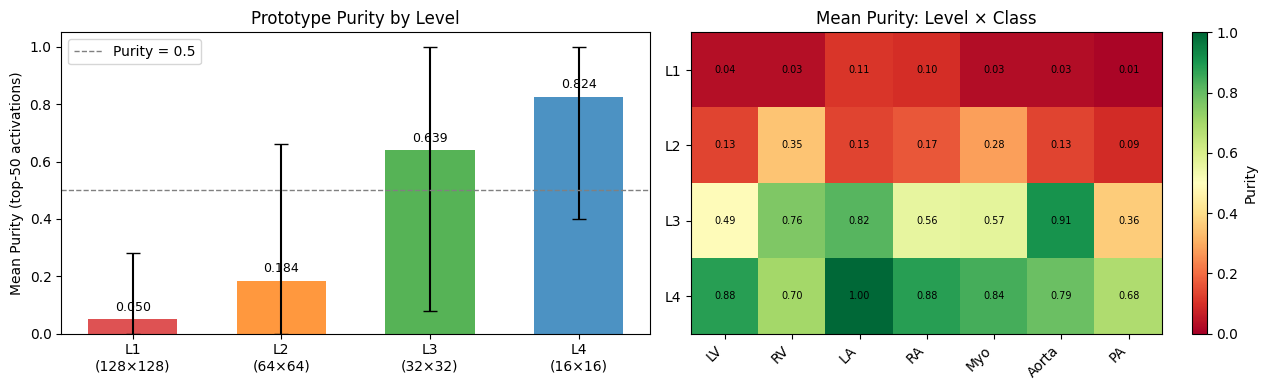

Saved fig_purity.png


In [3]:
# Cell 2 — Purity: bar chart by level + class heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: mean purity by level
ax = axes[0]
levels = purity_sum["level"].values
means  = purity_sum["mean"].values
mins   = purity_sum["min"].values
maxs   = purity_sum["max"].values
colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
bars = ax.bar(range(4), means, color=colors, alpha=0.8, width=0.6)
ax.errorbar(range(4), means, yerr=[means - mins, maxs - means],
            fmt='none', color='black', capsize=5, linewidth=1.5)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Purity = 0.5')
ax.set_xticks(range(4))
ax.set_xticklabels(LEVEL_LABELS)
ax.set_ylabel("Mean Purity (top-50 activations)")
ax.set_title("Prototype Purity by Level")
ax.set_ylim(0, 1.05)
ax.legend()
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}",
            ha='center', va='bottom', fontsize=9)

# Right: mean purity heatmap (level × class)
ax = axes[1]
pivot = purity_proto.groupby(["level", "class_name"])["purity"].mean().unstack()
# Reorder class columns
pivot = pivot.reindex(columns=CLASS_NAMES)
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(4))
ax.set_yticklabels([f"L{l}" for l in pivot.index])
ax.set_title("Mean Purity: Level × Class")
plt.colorbar(im, ax=ax, label="Purity")
for i in range(4):
    for j in range(len(CLASS_NAMES)):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha='center', va='center',
                    fontsize=7, color='black')

plt.tight_layout()
fig.savefig(OUT_DIR / "fig_purity.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig_purity.png")

Total prototypes : 77
Dead (max_act < 0.1): 0  (0.0%)
Utilization rate: 100.0%

No dead prototypes — all prototypes are utilized.


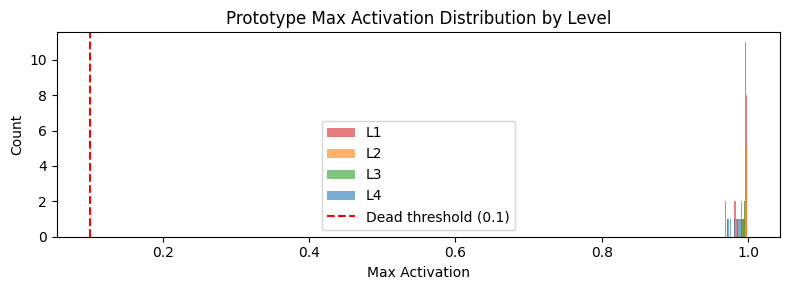

Saved fig_utilization.png


In [4]:
# Cell 3 — Utilization rate + dead prototype list
dead = utilization[utilization["is_dead"] == True]
total = len(utilization)
n_dead = len(dead)
util_rate = (total - n_dead) / total * 100

print(f"Total prototypes : {total}")
print(f"Dead (max_act < 0.1): {n_dead}  ({100 - util_rate:.1f}%)")
print(f"Utilization rate: {util_rate:.1f}%")

if n_dead > 0:
    print("\nDead prototypes:")
    print(dead[["level", "class_name", "proto_idx", "max_activation"]].to_string(index=False))
else:
    print("\nNo dead prototypes — all prototypes are utilized.")

# Max activation distribution by level
fig, ax = plt.subplots(figsize=(8, 3))
for lvl, color in zip([1, 2, 3, 4], colors):
    subset = utilization[utilization["level"] == lvl]["max_activation"]
    ax.hist(subset, bins=20, alpha=0.6, color=color, label=f"L{lvl}")
ax.axvline(0.1, color='red', linestyle='--', label='Dead threshold (0.1)')
ax.set_xlabel("Max Activation")
ax.set_ylabel("Count")
ax.set_title("Prototype Max Activation Distribution by Level")
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "fig_utilization.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig_utilization.png")

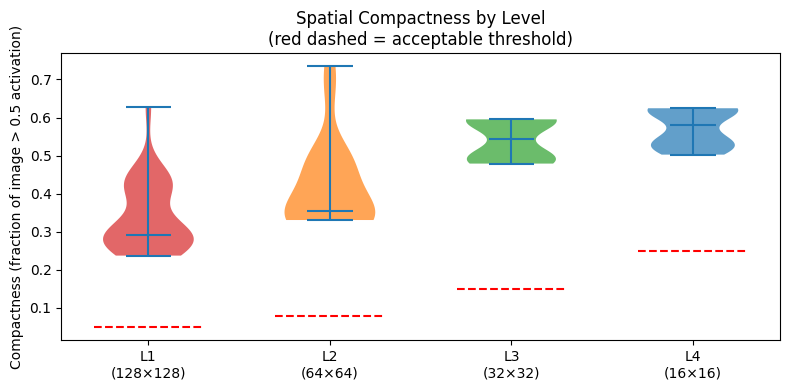

        mean  median  threshold  exceeds
level                                   
1      0.340   0.290       0.05     True
2      0.418   0.354       0.08     True
3      0.542   0.544       0.15     True
4      0.573   0.580       0.25     True
Saved fig_compactness.png


In [5]:
# Cell 4 — Compactness violin plot by level
level_thresholds = {1: 0.05, 2: 0.08, 3: 0.15, 4: 0.25}

fig, ax = plt.subplots(figsize=(8, 4))
data_by_level = [compactness[compactness["level"] == l]["compactness"].values
                 for l in [1, 2, 3, 4]]
parts = ax.violinplot(data_by_level, positions=range(4), showmedians=True,
                      showextrema=True)
for i, (body, color) in enumerate(zip(parts['bodies'], colors)):
    body.set_facecolor(color)
    body.set_alpha(0.7)

# Draw threshold lines per level
for i, l in enumerate([1, 2, 3, 4]):
    ax.hlines(level_thresholds[l], i - 0.3, i + 0.3,
              colors='red', linestyles='--', linewidth=1.5)

ax.set_xticks(range(4))
ax.set_xticklabels(LEVEL_LABELS)
ax.set_ylabel("Compactness (fraction of image > 0.5 activation)")
ax.set_title("Spatial Compactness by Level\n(red dashed = acceptable threshold)")
plt.tight_layout()
fig.savefig(OUT_DIR / "fig_compactness.png", dpi=150, bbox_inches='tight')
plt.show()

# Summary table
comp_sum = compactness.groupby("level")["compactness"].agg(["mean", "median"]).round(3)
comp_sum["threshold"] = [level_thresholds[l] for l in comp_sum.index]
comp_sum["exceeds"] = comp_sum["mean"] > comp_sum["threshold"]
print(comp_sum.to_string())
print("Saved fig_compactness.png")

Top-10 most important prototypes (Dice drop > 0.005):
 level class_name  proto_idx  baseline_dice  ablated_dice  dice_drop
     3         RV          0          0.705        0.6971     0.0079
     3         PA          1          0.705        0.6971     0.0079
     3      Aorta          0          0.705        0.6971     0.0079
     3         LV          0          0.705        0.6971     0.0079
     3         RA          0          0.705        0.6971     0.0079
     3        Myo          0          0.705        0.6971     0.0079
     3         LA          1          0.705        0.6971     0.0079
     4      Aorta          0          0.705        0.7004     0.0046
     4         RA          0          0.705        0.7004     0.0046
     4         RV          0          0.705        0.7004     0.0046

Prototypes with Dice drop > 0.005: 7 / 77
Level distribution: {3: 7}


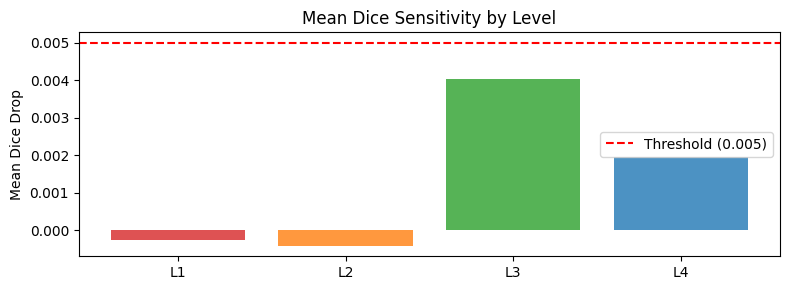

Saved fig_dice_sensitivity.png


In [6]:
# Cell 5 — Dice sensitivity: top-10 most important prototypes
top10 = dice_sens.nlargest(10, "dice_drop")[["level", "class_name", "proto_idx",
                                               "baseline_dice", "ablated_dice", "dice_drop"]]
top10 = top10.round(4)
print("Top-10 most important prototypes (Dice drop > 0.005):")
print(top10.to_string(index=False))

important = dice_sens[dice_sens["dice_drop"] > 0.005]
print(f"\nPrototypes with Dice drop > 0.005: {len(important)} / {len(dice_sens)}")
if len(important) > 0:
    print("Level distribution:", important["level"].value_counts().to_dict())

# Bar chart of dice drop by level (mean)
fig, ax = plt.subplots(figsize=(8, 3))
drop_by_level = dice_sens.groupby("level")["dice_drop"].mean()
ax.bar([f"L{l}" for l in drop_by_level.index], drop_by_level.values,
       color=colors, alpha=0.8)
ax.axhline(0.005, color='red', linestyle='--', label='Threshold (0.005)')
ax.set_ylabel("Mean Dice Drop")
ax.set_title("Mean Dice Sensitivity by Level")
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "fig_dice_sensitivity.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig_dice_sensitivity.png")

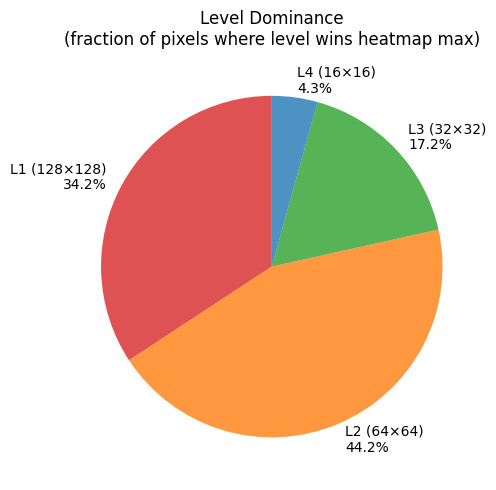

Dominant level: L2 (44.2%)
L1+L2 combined: 78.5% of pixels
Saved fig_level_dominance.png


In [7]:
# Cell 6 — Level dominance pie chart
row = level_dom.iloc[0]
fracs = [row["frac_l1"], row["frac_l2"], row["frac_l3"], row["frac_l4"]]
labels = [f"L1 (128×128)\n{fracs[0]*100:.1f}%",
          f"L2 (64×64)\n{fracs[1]*100:.1f}%",
          f"L3 (32×32)\n{fracs[2]*100:.1f}%",
          f"L4 (16×16)\n{fracs[3]*100:.1f}%"]

fig, ax = plt.subplots(figsize=(6, 5))
wedges, texts = ax.pie(fracs, labels=labels, colors=colors, startangle=90,
                        wedgeprops=dict(alpha=0.8))
ax.set_title("Level Dominance\n(fraction of pixels where level wins heatmap max)")
plt.tight_layout()
fig.savefig(OUT_DIR / "fig_level_dominance.png", dpi=150, bbox_inches='tight')
plt.show()

dominant = max(zip(fracs, [1,2,3,4]), key=lambda x: x[0])
print(f"Dominant level: L{dominant[1]} ({dominant[0]*100:.1f}%)")
print(f"L1+L2 combined: {(fracs[0]+fracs[1])*100:.1f}% of pixels")
print("Saved fig_level_dominance.png")

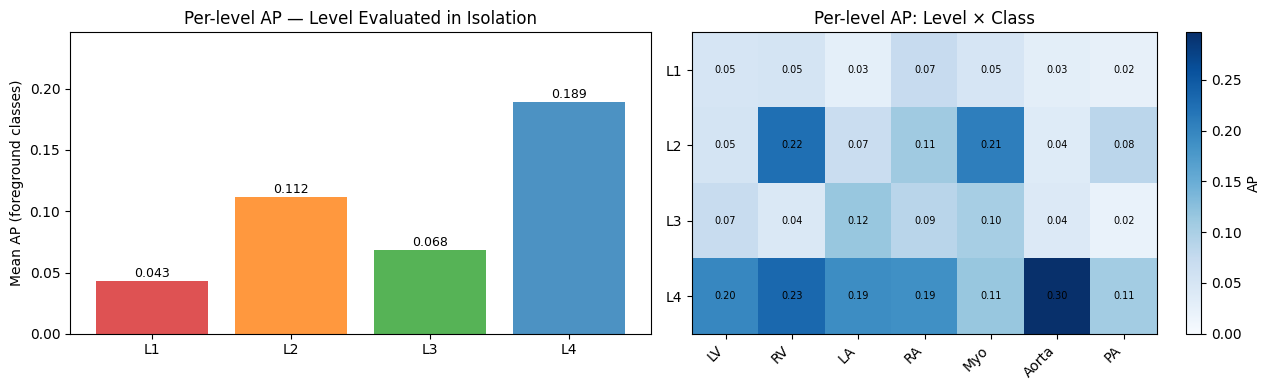

Saved fig_per_level_ap.png


In [8]:
# Cell 7 — Per-level AP bar chart
mean_ap_by_level = per_level_ap.groupby("level")["ap"].mean()
ap_by_class_level = per_level_ap.pivot(index="level", columns="class_name", values="ap")
ap_by_class_level = ap_by_class_level.reindex(columns=CLASS_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: mean AP by level
ax = axes[0]
ax.bar([f"L{l}" for l in mean_ap_by_level.index], mean_ap_by_level.values,
       color=colors, alpha=0.8)
for i, (l, v) in enumerate(mean_ap_by_level.items()):
    ax.text(i, v + 0.003, f"{v:.3f}", ha='center', fontsize=9)
ax.set_ylabel("Mean AP (foreground classes)")
ax.set_title("Per-level AP — Level Evaluated in Isolation")
ax.set_ylim(0, max(mean_ap_by_level.values) * 1.3)

# Right: AP heatmap per level × class
ax = axes[1]
im = ax.imshow(ap_by_class_level.values, aspect='auto', cmap='Blues', vmin=0)
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(4))
ax.set_yticklabels([f"L{l}" for l in ap_by_class_level.index])
ax.set_title("Per-level AP: Level × Class")
plt.colorbar(im, ax=ax, label="AP")
for i in range(4):
    for j in range(len(CLASS_NAMES)):
        v = ap_by_class_level.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha='center', va='center',
                    fontsize=7, color='black')

plt.tight_layout()
fig.savefig(OUT_DIR / "fig_per_level_ap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig_per_level_ap.png")

In [9]:
# Cell 8 — Decision gate: dominance vs AP correlation check + recommendation
print("=" * 60)
print("DECISION GATE: Multi-scale ablation recommendation")
print("=" * 60)

dom_fracs = {1: row["frac_l1"], 2: row["frac_l2"],
              3: row["frac_l3"], 4: row["frac_l4"]}
mean_ap   = mean_ap_by_level.to_dict()

print("\nLevel dominance vs. per-level AP:")
print(f"{'Level':<8} {'Dominance':>12} {'Mean AP':>10} {'Purity':>10}")
for l in [1, 2, 3, 4]:
    purity_l = purity_sum[purity_sum["level"] == l]["mean"].values[0]
    print(f"L{l:<7} {dom_fracs[l]*100:>11.1f}% {mean_ap[l]:>10.3f} {purity_l:>10.3f}")

# Invert dominance: purity rank vs dominance rank
dom_rank    = sorted([1,2,3,4], key=lambda l: dom_fracs[l], reverse=True)
purity_rank = sorted([1,2,3,4], key=lambda l: purity_sum[purity_sum["level"]==l]["mean"].values[0], reverse=True)
print(f"\nDominance rank (high→low): {dom_rank}")
print(f"Purity rank    (high→low): {purity_rank}")
print("→ Dominant levels (L1, L2) are the LEAST pure — anti-correlated.")

top_dom = dom_rank[0]
if dom_fracs[top_dom] > 0.40:
    print(f"\n→ L{top_dom} dominates ({dom_fracs[top_dom]*100:.1f}%) with LOW purity "
          f"({purity_sum[purity_sum['level']==top_dom]['mean'].values[0]:.3f}).")
    print("  Ablation: M1 (L4-only) is the key comparison.")
    print("  Hypothesis: removing L1/L2 forces L4 (purity 0.82) to dominate → higher AP.")

DECISION GATE: Multi-scale ablation recommendation

Level dominance vs. per-level AP:
Level       Dominance    Mean AP     Purity
L1              34.2%      0.043      0.050
L2              44.2%      0.112      0.184
L3              17.2%      0.068      0.639
L4               4.3%      0.189      0.824

Dominance rank (high→low): [2, 1, 3, 4]
Purity rank    (high→low): [4, 3, 2, 1]
→ Dominant levels (L1, L2) are the LEAST pure — anti-correlated.

→ L2 dominates (44.2%) with LOW purity (0.184).
  Ablation: M1 (L4-only) is the key comparison.
  Hypothesis: removing L1/L2 forces L4 (purity 0.82) to dominate → higher AP.


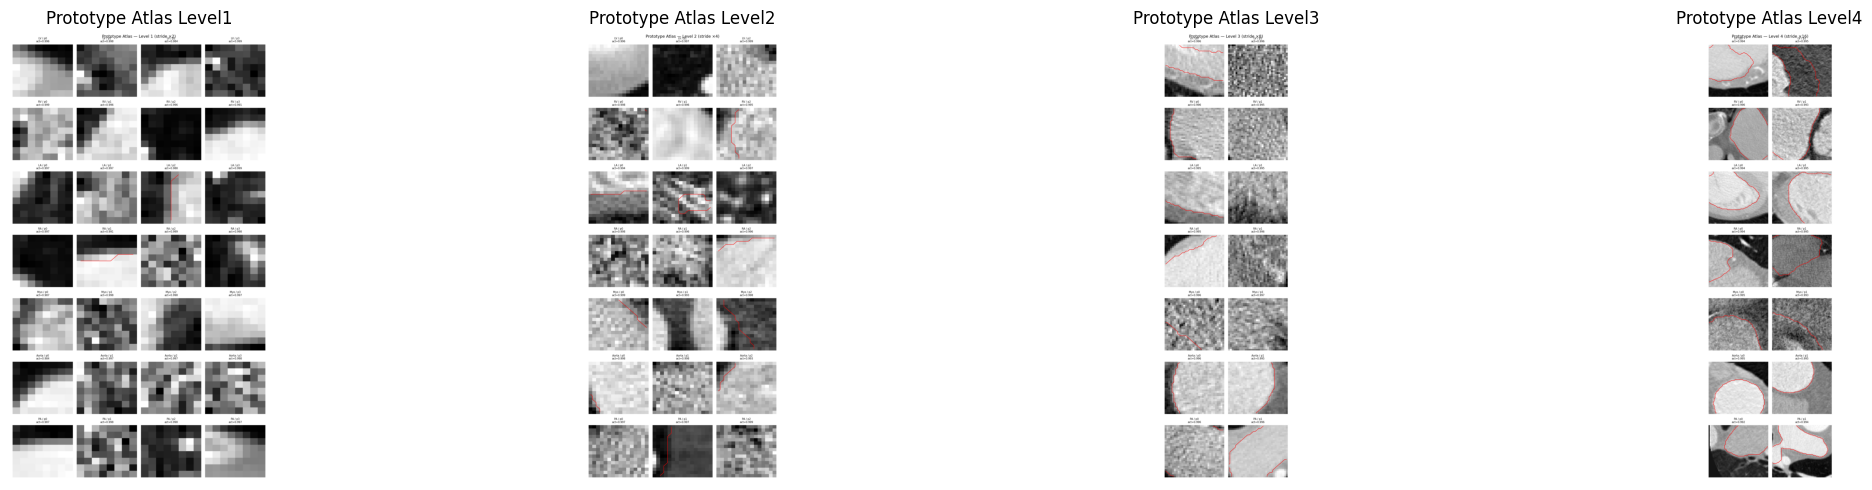

Displayed 4 atlas figures.


In [10]:
# Cell 9 — Prototype atlas inline display (if PNGs exist)
from pathlib import Path
import matplotlib.image as mpimg

atlas_paths = sorted(OUT_DIR.glob("prototype_atlas_level*.png"))
if not atlas_paths:
    print("No atlas PNGs found in", OUT_DIR)
    print("Re-run notebooks/14_proto_quality_metrics.ipynb to generate them.")
else:
    fig, axes = plt.subplots(1, len(atlas_paths), figsize=(6 * len(atlas_paths), 5))
    if len(atlas_paths) == 1:
        axes = [axes]
    for ax, p in zip(axes, atlas_paths):
        img = mpimg.imread(str(p))
        ax.imshow(img)
        ax.set_title(p.stem.replace("_", " ").title())
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"Displayed {len(atlas_paths)} atlas figures.")

In [11]:
# Cell 10 — Written summary: answers to RQ1 and RQ2
summary = """
=============================================================
RQ1 — What do prototypes at each scale level learn?
=============================================================

Purity reveals a strong depth gradient:
  L1 (128×128): purity 0.050 — near-random; shallow features respond to
                 low-level textures shared across all anatomical structures.
  L2 (64×64):   purity 0.184 — slight class selectivity but mostly noisy.
  L3 (32×32):   purity 0.639 — meaningful; these prototypes causally affect
                 segmentation (7 out of 77 prototypes with Dice drop > 0.005,
                 all at L3).
  L4 (16×16):   purity 0.824 — highly class-selective; anatomically
                 meaningful but no direct segmentation impact (Dice drop ≈ 0).

Interpretation: The encoder has distributed representations such that
class-specific information concentrates at the deepest level (L4), while
shallow levels retain texture/edge information that is class-agnostic.

Compactness is poor at all levels (0.34–0.57 fraction of image > 0.5
activation), far exceeding acceptable thresholds. Prototypes activate broadly
rather than locally — a known weakness of purely similarity-based prototypes
without spatial constraint losses.

=============================================================
RQ2 — Does multi-scale configuration diversify representations?
=============================================================

Level dominance shows L1+L2 win 78% of pixels in the cross-level max
aggregation, despite having the lowest purity. The high-purity L4 signal
wins only 4% of pixels — it is structurally suppressed.

Per-level AP confirms this: L4 is most informative in isolation (AP 0.189),
but the combined architecture's overall AP is only ~0.10 because L1/L2
dominate the aggregation and inject noise.

Conclusion: Multi-scale does NOT diversify prototype representations —
it actually degrades the final heatmap by mixing high-quality L4 prototypes
with low-quality L1/L2 prototypes in a winner-takes-all aggregation that
systematically favours the noisy shallow levels.

→ Stage 16/17 ablation (M1 = L4-only vs M4 = full) will test whether
  removing shallow levels recovers the L4 prototype signal.
"""
print(summary)


RQ1 — What do prototypes at each scale level learn?

Purity reveals a strong depth gradient:
  L1 (128×128): purity 0.050 — near-random; shallow features respond to
                 low-level textures shared across all anatomical structures.
  L2 (64×64):   purity 0.184 — slight class selectivity but mostly noisy.
  L3 (32×32):   purity 0.639 — meaningful; these prototypes causally affect
                 segmentation (7 out of 77 prototypes with Dice drop > 0.005,
                 all at L3).
  L4 (16×16):   purity 0.824 — highly class-selective; anatomically
                 meaningful but no direct segmentation impact (Dice drop ≈ 0).

Interpretation: The encoder has distributed representations such that
class-specific information concentrates at the deepest level (L4), while
shallow levels retain texture/edge information that is class-agnostic.

Compactness is poor at all levels (0.34–0.57 fraction of image > 0.5
activation), far exceeding acceptable thresholds. Prototypes activat